In [1]:
!pip install -q transformers datasets accelerate sentencepiece

In [2]:
import torch
import time
import json
import os
import shutil

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

def not_empty(example):
    return example["text"] is not None and example["text"].strip() != ""

dataset["train"] = dataset["train"].filter(not_empty)
dataset["validation"] = dataset["validation"].filter(not_empty)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/36718 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 23767
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 2461
    })
})


In [4]:
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
small_train = dataset["train"].select(range(500))
small_valid = dataset["validation"].select(range(100))

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

tokenized_train = small_train.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_valid = small_valid.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask"])
tokenized_valid.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [6]:
train_loader = DataLoader(tokenized_train, batch_size=8, shuffle=True)
valid_loader = DataLoader(tokenized_valid, batch_size=8)

In [7]:
model = AutoModelForCausalLM.from_pretrained("distilgpt2")
model.resize_token_embeddings(len(tokenizer))
model = model.to(device)

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [8]:
optimizer = AdamW(model.parameters(), lr=5e-5)

In [9]:
model.train()
total_loss = 0

for step, batch in enumerate(train_loader):

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=input_ids
    )

    loss = outputs.loss
    total_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")

    if step == 100:
        break

avg_loss = total_loss / (step + 1)
print(f"Average training loss: {avg_loss:.4f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step 0, Loss: 7.0058
Step 20, Loss: 2.3511
Step 40, Loss: 2.0583
Step 60, Loss: 2.5117
Average training loss: 2.8405


In [10]:
model.eval()
val_loss = 0
num_batches = 0

with torch.no_grad():
    for batch in valid_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )

        val_loss += outputs.loss.item()
        num_batches += 1

print("Validation loss:", val_loss / num_batches)

Validation loss: 2.964748731026283


In [11]:
checkpoint_path = "checkpoint.pt"

torch.save({
    "step": 100,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, checkpoint_path)

print("Checkpoint saved")

Checkpoint saved


In [12]:
recovered_model = AutoModelForCausalLM.from_pretrained("distilgpt2")
recovered_model.resize_token_embeddings(len(tokenizer))
recovered_model = recovered_model.to(device)

recovered_optimizer = AdamW(recovered_model.parameters(), lr=5e-5)

checkpoint = torch.load(checkpoint_path, map_location=device)

recovered_model.load_state_dict(checkpoint["model_state_dict"])
recovered_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_step = checkpoint["step"] + 1

print("Recovered from step:", start_step)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Recovered from step: 101


In [13]:
recovered_model.train()

for step, batch in enumerate(train_loader, start=start_step):

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    outputs = recovered_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=input_ids
    )

    loss = outputs.loss

    recovered_optimizer.zero_grad()
    loss.backward()
    recovered_optimizer.step()

    if step % 10 == 0:
        print(f"Resumed Step {step}, Loss: {loss.item():.4f}")

    if step == start_step + 20:
        break

Resumed Step 110, Loss: 2.8811
Resumed Step 120, Loss: 2.6440


In [14]:
timed_model = AutoModelForCausalLM.from_pretrained("distilgpt2")
timed_model.resize_token_embeddings(len(tokenizer))
timed_model = timed_model.to(device)

timed_optimizer = AdamW(timed_model.parameters(), lr=5e-5)

timed_model.train()

num_steps = 20
total_samples = 0
step_times = []

start_total = time.time()

for step, batch in enumerate(train_loader):
    if step >= num_steps:
        break

    step_start = time.time()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    outputs = timed_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=input_ids
    )

    loss = outputs.loss

    timed_optimizer.zero_grad()
    loss.backward()
    timed_optimizer.step()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    step_end = time.time()

    step_times.append(step_end - step_start)
    total_samples += input_ids.size(0)

end_total = time.time()

total_time = end_total - start_total
avg_step_time = sum(step_times) / len(step_times)
throughput = total_samples / total_time

print("Total time:", total_time)
print("Avg step time:", avg_step_time)
print("Throughput:", throughput)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total time: 110.41637086868286
Avg step time: 5.519153916835785
Throughput: 1.4490604856981442


In [15]:
performance_results = {
    "total_time_sec": total_time,
    "avg_step_time_sec": avg_step_time,
    "throughput": throughput
}

with open("performance_results.json", "w") as f:
    json.dump(performance_results, f, indent=2)

print("Saved performance results")

Saved performance results


In [16]:
prompt = "Large language models require distributed training because"

inputs = tokenizer(prompt, return_tensors="pt").to(device)

model.eval()

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_length=60,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id
    )

generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

print(generated_text)

Large language models require distributed training because the language is very broad and varied with multiple languages and the language is the only one for which it can be used as an instrument of speech, thus producing a wide range of interpretations. The language of the language of the human person can also be translated into English .


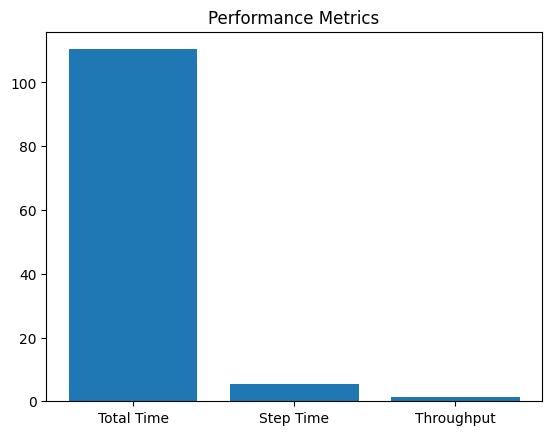

In [17]:
import matplotlib.pyplot as plt

metrics = ["Total Time", "Step Time", "Throughput"]
values = [total_time, avg_step_time, throughput]

plt.bar(metrics, values)
plt.title("Performance Metrics")
plt.show()

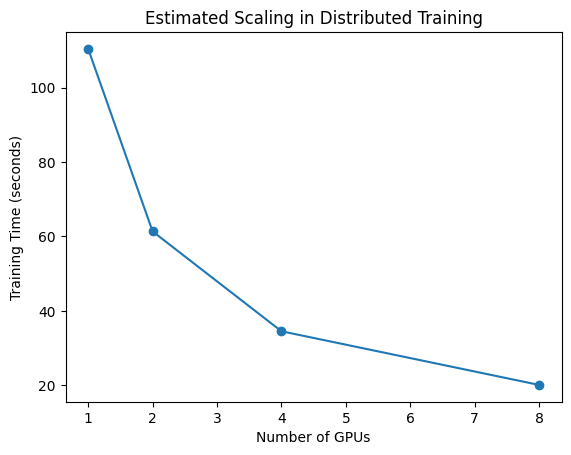

In [18]:
import matplotlib.pyplot as plt

# Current total time (from your experiment)
single_gpu_time = total_time

# Simulated scaling (ideal + slight inefficiency)
gpus = [1, 2, 4, 8]
times = [
    single_gpu_time,
    single_gpu_time / 1.8,   # not perfect 2x due to overhead
    single_gpu_time / 3.2,
    single_gpu_time / 5.5
]

plt.figure()
plt.plot(gpus, times, marker='o')
plt.xlabel("Number of GPUs")
plt.ylabel("Training Time (seconds)")
plt.title("Estimated Scaling in Distributed Training")
plt.show()